# Task 2: Hourly Pollutant Forecasting — Production Pipeline

**Model**: LightGBM ensemble with Fourier features, anchor lags, target encoding, and 90% prediction intervals.

**Ensemble**: Optimized weighted average of LightGBM + Ridge (Fourier) + Seasonal Naive.

**Validation**: Walk-forward CV with 720-hour (30-day) test windows.

In [1]:
import sys, os
sys.path.insert(0, '..')
os.makedirs("../outputs", exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import load_series
from src.forecasting.train import (
    train_forecast_pipeline, predict_with_pipeline, 
    seasonal_naive_predict, walk_forward_cv
)
from src.forecasting.evaluate import evaluate_predictions, evaluate_intervals
from src.utils.constants import FORECAST_TARGETS

print(f"Targets: {len(FORECAST_TARGETS)}")
for t in FORECAST_TARGETS:
    print(f"  Station {t['station_code']}/{t['item_name']} → {t['start']} to {t['end']}")

Targets: 6
  Station 206/so2 → 2023-07-01 to 2023-07-31 23:00:00
  Station 211/no2 → 2023-08-01 to 2023-08-31 23:00:00
  Station 217/o3 → 2023-09-01 to 2023-09-30 23:00:00
  Station 219/co → 2023-10-01 to 2023-10-31 23:00:00
  Station 225/pm10 → 2023-11-01 to 2023-11-30 23:00:00
  Station 228/pm2.5 → 2023-12-01 to 2023-12-31 23:00:00


In [2]:
results = []
all_predictions = {}

for target in FORECAST_TARGETS:
    sc, ic, name = target["station_code"], target["item_code"], target["item_name"]
    pred_start, pred_end = target["start"], target["end"]
    
    print(f"\n{'='*70}")
    print(f"Station {sc} / {name} | Predict: {pred_start} to {pred_end}")
    print(f"{'='*70}")
    
    # Load and prepare training data
    raw = load_series(sc, ic, normal_only=True, end_before=pred_start)
    ts = raw["clean_value"].copy()
    full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq="h")
    ts = ts.reindex(full_idx).ffill().bfill()
    overall_std = ts.std()
    
    print(f"Training: {len(ts)} hours | Overall std: {overall_std:.5f}")
    
    # --- Walk-forward cross-validation ---
    folds = walk_forward_cv(ts, n_folds=3, test_size=720, min_train_size=8760)
    cv_metrics = {"naive": [], "lgbm": [], "ensemble": []}
    cv_intervals = []
    
    for fold in folds:
        fold_train = ts.iloc[:fold["train_end"]]
        fold_test = ts.iloc[fold["test_start"]:fold["test_end"]]
        
        pipeline = train_forecast_pipeline(fold_train, fold_test)
        preds = predict_with_pipeline(pipeline, fold_test.index)
        
        for model_name, col in [("naive", "naive"), ("lgbm", "lgbm"), ("ensemble", "ensemble")]:
            m = evaluate_predictions(fold_test, preds[col])
            # Use overall std for nRMSE (not fold-specific std)
            m["nrmse_overall"] = m["rmse"] / overall_std
            cv_metrics[model_name].append(m)
        
        iv = evaluate_intervals(fold_test.values, preds["q05"].values, preds["q95"].values)
        cv_intervals.append(iv)
    
    # Average CV metrics
    for model_name in cv_metrics:
        avg = {k: np.mean([m[k] for m in cv_metrics[model_name]]) for k in cv_metrics[model_name][0]}
        print(f"  {model_name:>8}: RMSE={avg['rmse']:.5f}, nRMSE={avg['nrmse_overall']:.3f}, "
              f"R²={avg['r2']:.3f}, MAE={avg['mae']:.5f}")
    
    avg_iv = {k: np.mean([iv[k] for iv in cv_intervals]) for k in cv_intervals[0]}
    print(f"  Intervals: coverage={avg_iv['empirical_coverage']:.3f} (target 0.90), "
          f"avg_width={avg_iv['avg_interval_width']:.5f}")
    
    # --- Final: retrain on ALL data, predict target period ---
    val_start = ts.index.max() - pd.DateOffset(months=1) + pd.Timedelta(hours=1)
    train_final = ts.loc[:val_start - pd.Timedelta(hours=1)]
    val_final = ts.loc[val_start:]
    
    final_pipeline = train_forecast_pipeline(train_final, val_final)
    # Retrain on full data for final prediction
    full_pipeline = train_forecast_pipeline(ts)
    # But use validation-optimized weights
    full_pipeline["weights"] = final_pipeline["weights"]
    
    pred_index = pd.date_range(pred_start, pred_end, freq="h")
    final_preds = predict_with_pipeline(full_pipeline, pred_index)
    
    print(f"\n  Ensemble weights: { {k: round(v, 3) for k, v in full_pipeline['weights'].items()} }")
    print(f"  Predictions: {len(final_preds)} hours")
    print(f"    Ensemble range: [{final_preds['ensemble'].min():.5f}, {final_preds['ensemble'].max():.5f}]")
    print(f"    90% PI width:   [{(final_preds['q95']-final_preds['q05']).mean():.5f}]")
    
    # Store results
    avg_ensemble = {k: np.mean([m[k] for m in cv_metrics["ensemble"]]) for k in cv_metrics["ensemble"][0]}
    avg_naive = {k: np.mean([m[k] for m in cv_metrics["naive"]]) for k in cv_metrics["naive"][0]}
    
    results.append({
        "station": sc, "pollutant": name,
        "cv_naive_rmse": round(avg_naive["rmse"], 5),
        "cv_ensemble_rmse": round(avg_ensemble["rmse"], 5),
        "cv_nrmse": round(avg_ensemble["nrmse_overall"], 3),
        "cv_r2": round(avg_ensemble["r2"], 3),
        "improvement_%": round((1 - avg_ensemble["rmse"] / avg_naive["rmse"]) * 100, 1),
        "interval_coverage": round(avg_iv["empirical_coverage"], 3),
    })
    
    all_predictions[f"{sc}_{name}"] = {
        "final": final_preds,
        "cv_last_fold_preds": preds,
        "cv_last_fold_actual": fold_test,
    }

print("\n\nAll targets processed.")


Station 206 / so2 | Predict: 2023-07-01 to 2023-07-31 23:00:00
Training: 21864 hours | Overall std: 0.00133


     naive: RMSE=0.00142, nRMSE=1.068, R²=-0.796, MAE=0.00114
      lgbm: RMSE=0.00114, nRMSE=0.859, R²=-0.083, MAE=0.00089
  ensemble: RMSE=0.00122, nRMSE=0.919, R²=-0.280, MAE=0.00099
  Intervals: coverage=0.621 (target 0.90), avg_width=0.00329



  Ensemble weights: {'lgbm': np.float64(0.333), 'ridge': np.float64(0.333), 'naive': np.float64(0.333)}
  Predictions: 744 hours
    Ensemble range: [0.00239, 0.00388]
    90% PI width:   [0.00186]

Station 211 / no2 | Predict: 2023-08-01 to 2023-08-31 23:00:00
Training: 22608 hours | Overall std: 0.01574


     naive: RMSE=0.01364, nRMSE=0.866, R²=-1.369, MAE=0.01153
      lgbm: RMSE=0.00930, nRMSE=0.591, R²=0.066, MAE=0.00751
  ensemble: RMSE=0.01041, nRMSE=0.661, R²=-0.230, MAE=0.00859
  Intervals: coverage=0.824 (target 0.90), avg_width=0.02844



  Ensemble weights: {'lgbm': np.float64(0.333), 'ridge': np.float64(0.333), 'naive': np.float64(0.333)}
  Predictions: 744 hours
    Ensemble range: [0.01017, 0.02957]
    90% PI width:   [0.02030]

Station 217 / o3 | Predict: 2023-09-01 to 2023-09-30 23:00:00
Training: 23352 hours | Overall std: 0.01997


...


  Ensemble weights: {'lgbm': np.float64(0.364), 'ridge': np.float64(0.265), 'naive': np.float64(0.371)}
  Predictions: 744 hours
    Ensemble range: [0.37054, 0.84044]
    90% PI width:   [0.40907]

Station 225 / pm10 | Predict: 2023-11-01 to 2023-11-30 23:00:00
Training: 24816 hours | Overall std: 32.96530


     naive: RMSE=28.09975, nRMSE=0.852, R²=-2.622, MAE=23.43911
      lgbm: RMSE=18.07610, nRMSE=0.548, R²=-0.026, MAE=13.27913
  ensemble: RMSE=17.28982, nRMSE=0.524, R²=0.039, MAE=12.15061
  Intervals: coverage=0.827 (target 0.90), avg_width=39.61892



  Ensemble weights: {'lgbm': np.float64(0.0), 'ridge': np.float64(1.0), 'naive': np.float64(0.0)}
  Predictions: 720 hours
    Ensemble range: [33.16545, 57.37007]
    90% PI width:   [95.67123]

Station 228 / pm2.5 | Predict: 2023-12-01 to 2023-12-31 23:00:00
Training: 25536 hours | Overall std: 18.68449


     naive: RMSE=14.03014, nRMSE=0.751, R²=-0.970, MAE=11.21808
      lgbm: RMSE=11.25144, nRMSE=0.602, R²=-0.270, MAE=9.01880
  ensemble: RMSE=9.80707, nRMSE=0.525, R²=0.081, MAE=7.55021
  Intervals: coverage=0.870 (target 0.90), avg_width=35.23388



  Ensemble weights: {'lgbm': np.float64(1.0), 'ridge': np.float64(0.0), 'naive': np.float64(0.0)}
  Predictions: 744 hours
    Ensemble range: [16.98217, 32.17377]
    90% PI width:   [18.46928]


All targets processed.


In [3]:
# Results summary
results_df = pd.DataFrame(results)
print("Walk-Forward CV Results (3 folds × 720h):\n")
print(results_df.to_string(index=False))

Walk-Forward CV Results (3 folds × 720h):

 station pollutant  cv_naive_rmse  cv_ensemble_rmse  cv_nrmse  cv_r2  improvement_%  interval_coverage
     206       so2        0.00142           0.00122     0.919 -0.280           14.0              0.621
     211       no2        0.01364           0.01041     0.661 -0.230           23.6              0.824
     217        o3        0.01572           0.01438     0.720  0.355            8.5              0.889
     219        co        0.18147           0.13296     0.447  0.018           26.7              0.865
     225      pm10       28.09975          17.28982     0.524  0.039           38.5              0.827
     228     pm2.5       14.03014           9.80707     0.525  0.081           30.1              0.870


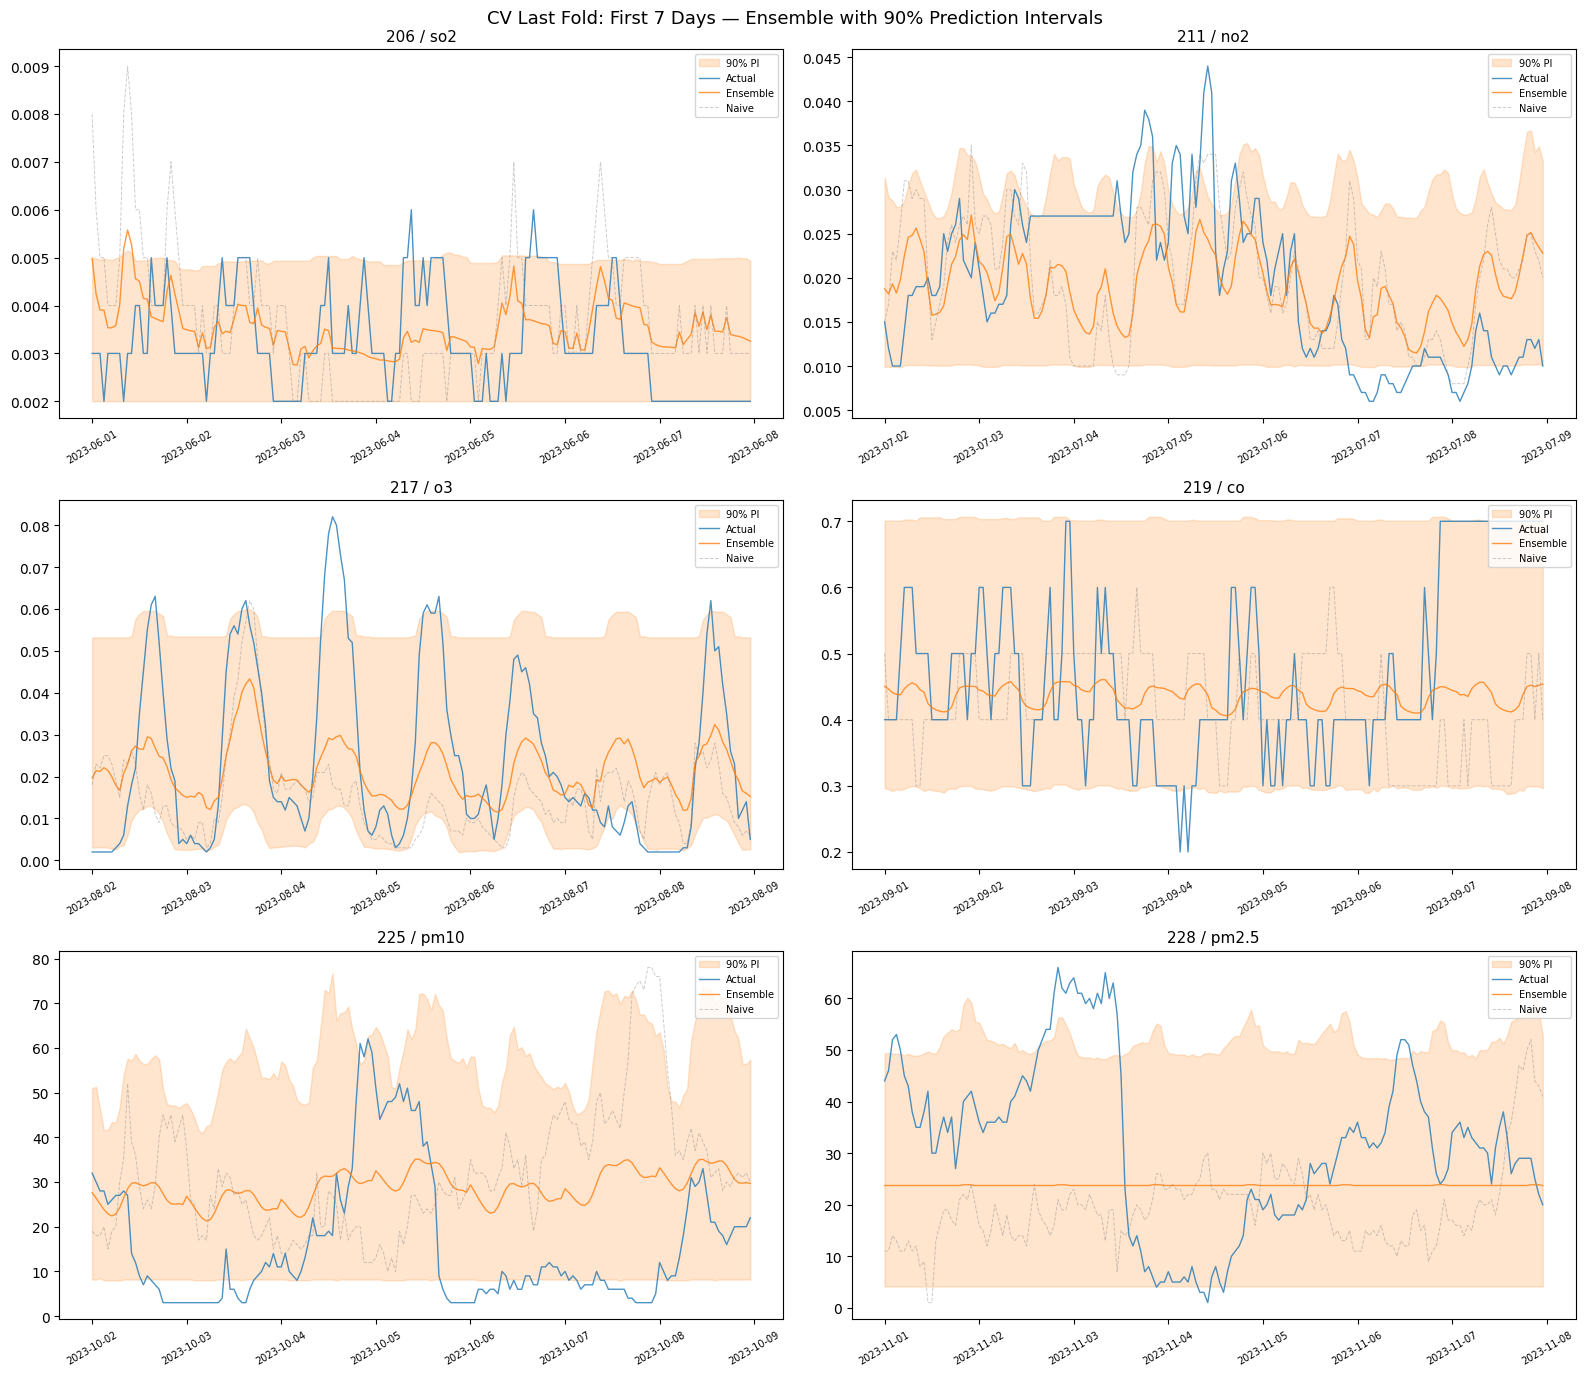

In [4]:
# Plot: last CV fold — actual vs ensemble with prediction intervals
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (key, data) in enumerate(all_predictions.items()):
    ax = axes[i]
    actual = data["cv_last_fold_actual"]
    preds = data["cv_last_fold_preds"]
    
    # Show first 7 days
    n = min(168, len(actual))
    t = actual.index[:n]
    
    ax.fill_between(t, preds["q05"].iloc[:n], preds["q95"].iloc[:n], 
                     alpha=0.2, color="C1", label="90% PI")
    ax.plot(t, actual.iloc[:n], linewidth=1, alpha=0.8, label="Actual", color="C0")
    ax.plot(t, preds["ensemble"].iloc[:n], linewidth=1, alpha=0.8, label="Ensemble", color="C1")
    ax.plot(t, preds["naive"].iloc[:n], linewidth=0.7, alpha=0.4, label="Naive", 
            color="gray", linestyle="--")
    
    ax.set_title(key.replace("_", " / "), fontsize=11)
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle("CV Last Fold: First 7 Days — Ensemble with 90% Prediction Intervals", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/forecast_validation_v2.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Export final predictions
all_exports = []
for target in FORECAST_TARGETS:
    key = f"{target['station_code']}_{target['item_name']}"
    preds = all_predictions[key]["final"]
    df = pd.DataFrame({
        "measurement_datetime": preds.index,
        "station_code": target["station_code"],
        "item_code": target["item_code"],
        "item_name": target["item_name"],
        "predicted_value": preds["ensemble"].values,
        "predicted_lower_90": preds["q05"].values,
        "predicted_upper_90": preds["q95"].values,
    })
    all_exports.append(df)

export_df = pd.concat(all_exports, ignore_index=True)
export_df.to_csv("../outputs/forecast_predictions.csv", index=False)
print(f"Exported {len(export_df)} predictions with 90% intervals")
print(export_df.groupby(["station_code", "item_name"]).agg(
    count=("predicted_value", "count"),
    mean=("predicted_value", lambda x: round(x.mean(), 5)),
    min=("predicted_value", lambda x: round(x.min(), 5)),
    max=("predicted_value", lambda x: round(x.max(), 5)),
).to_string())

Exported 4416 predictions with 90% intervals
                        count      mean       min       max
station_code item_name                                     
206          so2          744   0.00318   0.00239   0.00388
211          no2          744   0.02154   0.01017   0.02957
217          o3           720   0.02707   0.00810   0.05405
219          co           744   0.55892   0.37054   0.84044
225          pm10         720  45.65025  33.16545  57.37007
228          pm2.5        744  23.43207  16.98217  32.17377
